# Quantum Phase Estimation: Single-Qubit Phase Gate
**Course module: AyushDocs-ExplorationTarget**

Welcome to this Jupyter notebook! In this guide, we will explore the fundamental concept of **Quantum Phase Estimation (QPE)**, a core subroutine in many advanced quantum algorithms (like Shor's algorithm and quantum phase estimation for chemistry).

---

## 1. Introduction to Quantum Phase Estimation (QPE)

The goal of QPE is to estimate the unknown phase $\phi$ of an eigenvalue of a unitary operator $U$. Specifically, given a unitary operator $U$ and an eigenstate $|\psi\rangle$ such that:

$$U |\psi\rangle = e^{2\pi i \phi} |\psi\rangle$$

where $0 \le \phi < 1$, QPE allows us to estimate $\phi$ up to $n$ bits of precision using $n$ auxiliary (or *ancilla*) qubits.

### How QPE Works
QPE relies on three main stages:
1. **Superposition and Phase Kickback**: We initialize $n$ ancilla qubits in the $|0\rangle^{\otimes n}$ state, apply Hadamard gates $H^{\otimes n}$ to create a uniform superposition, and then apply controlled-$U^{2^j}$ operations between each ancilla qubit $j$ and the target register containing $|\psi\rangle$. Due to **phase kickback**, the phase of the eigenvalues is "kicked back" into the state of the ancilla register.
2. **Inverse Quantum Fourier Transform ($QFT^\dagger$)**: The phase kickback leaves the ancilla register in a state related to the Fourier transform of $\phi$. Applying $QFT^\dagger$ converts this state back to the computational basis.
3. **Measurement**: Measuring the ancilla register yields a bitstring representing the binary fraction expansion of $\phi$:
   $$\phi \approx 0.\phi_1 \phi_2 \dots \phi_n = \sum_{j=1}^n \frac{\phi_j}{2^j}$$

---

## 2. Exploration Target: Single-Qubit Phase Gate

In this notebook, our target unitary is the single-qubit phase gate $P(\theta)$, defined as:

$$P(\theta) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\theta} \end{pmatrix}$$

If we prepare the target qubit in the state $|1\rangle$, it is an eigenstate of $P(\theta)$ with eigenvalue $e^{i\theta}$. Thus, the phase we want to estimate is:

$$\phi = \frac{\theta \pmod{2\pi}}{2\pi}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator

## 3. Designing the QPE Circuit

In [2]:
def qpe_phase_gate(theta, num_ancilla):
    """
    Constructs a QPE circuit for a single-qubit phase gate P(theta) on the target state |1>.
    """
    n = num_ancilla
    # Total qubits = n ancilla + 1 target qubit
    qc = QuantumCircuit(n + 1, n)
    target = n            # last qubit is the target
    ancillas = list(range(n))

    # Prepare target qubit in eigenstate |1>
    qc.x(target)

    # Apply Hadamard gates to ancilla qubits to create superposition
    qc.h(ancillas)

    # Apply controlled-U^(2^j) operations
    for j in range(n):
        # The phase gate is cp(2^j * theta, control, target)
        qc.cp(2**j * theta, ancillas[j], target)

    # Apply the inverse Quantum Fourier Transform to the ancillas
    qc.compose(QFTGate(n).inverse(), ancillas, inplace=True)

    # Measure the ancillas
    qc.measure(ancillas, list(range(n)))
    return qc

## 4. Visualization of a Small QPE Circuit

Let's build a circuit with $n=4$ ancilla qubits and draw it to inspect the structure.

In [3]:
theta_sample = 2 * np.pi * 0.4  # true phase phi = 0.4
for n_val in range(2, 11):
    qc_val = qpe_phase_gate(theta_sample, n_val)
    fig_val = qc_val.draw("mpl", fold=-1)
    fig_val.savefig(f"../frontend/public/qpe_circuit_n{n_val}.png", dpi=150)
    fig_val.savefig(f"../docs/qpe_circuit_n{n_val}.png", dpi=150)
    plt.close(fig_val)

qc_sample = qpe_phase_gate(theta_sample, 4)
print(f"Circuit depth: {qc_sample.depth()}")
print(f"Total gates: {qc_sample.size()}")
fig = qc_sample.draw("mpl", fold=-1)
plt.show()

Circuit depth: 7
Total gates: 14


## 5. Simulating and Running QPE

Now let's write functions to run the QPE circuit on the local Aer simulator, extract the phase from the measurement counts, and plot the outcome distribution.

In [4]:
SIM = AerSimulator()

def _run(qc, shots, sim=None):
    qct = transpile(qc, sim or SIM)
    return (sim or SIM).run(qct, shots=shots).result().get_counts()

def run_qpe_phase(theta, num_ancilla, shots=20000):
    qc = qpe_phase_gate(theta, num_ancilla)
    counts = _run(qc, shots)
    total = sum(counts.values())

    # Calculate the weighted average phase estimate
    phase_est = 0.0
    for bits, c in counts.items():
        # Convert binary string (little-endian order) to fraction
        frac = sum(int(bits[i]) / (1 << (i + 1)) for i in range(len(bits)))
        phase_est += frac * c / total

    true_phase = (theta % (2 * np.pi)) / (2 * np.pi)
    raw_err = abs(phase_est - true_phase)
    error = min(raw_err, 1.0 - raw_err)
    return phase_est, true_phase, error, counts

def plot_counts(counts, true_phase, n, save=None):
    labels = sorted(counts.keys())
    vals = [counts[k] for k in labels]
    total = sum(vals)
    phases = [sum(int(l[i]) / (1 << (i + 1)) for i in range(len(l))) for l in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(phases, [v / total for v in vals],
           width=1.0 / (1 << n) * 0.8, alpha=0.7,
           color="steelblue", edgecolor="navy")
    ax.axvline(true_phase, color="red", ls="--", lw=2,
               label=f"True φ = {true_phase:.4f}")
    ax.set_xlabel("Estimated phase (binary fraction)")
    ax.set_ylabel("Probability")
    ax.set_title(f"QPE Outcome Distribution (n={n})")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150)
        print(f"Saved plot to {save}")
    plt.show()

## 6. Execution and Analysis

Let's run the simulation for $\theta = 2\pi \times 0.4$ (a non-dyadic phase, meaning it cannot be written exactly as a finite binary fraction) using $n=8$ ancilla qubits.

True Phase (phi_true) = 0.400000
Estimated Phase (phi_est) = 0.399815
Absolute Error = 1.85e-04


Saved plot to ../docs/qpe_counts_n8.png


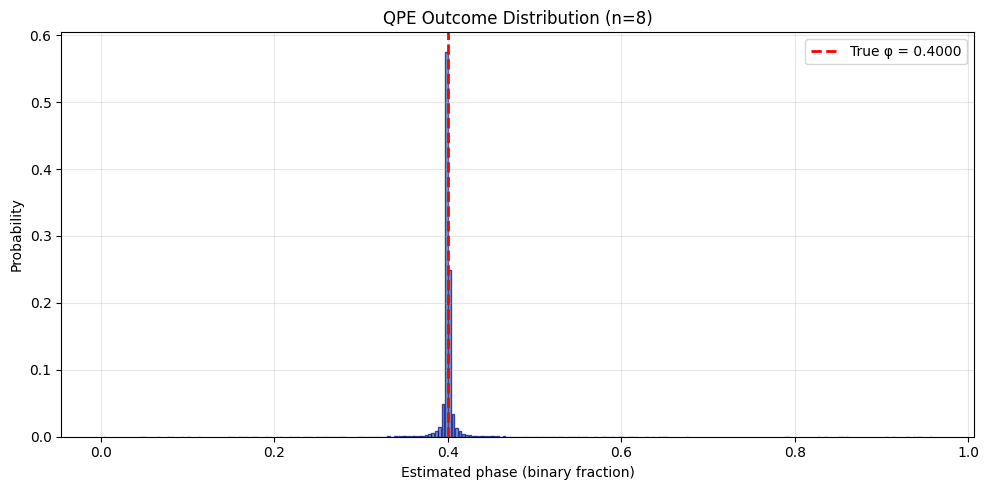

In [5]:
THETA = 2 * np.pi * 0.4
SHOTS = 20000
n8 = 8

est, true, err, counts8 = run_qpe_phase(THETA, n8, SHOTS)

print(f"True Phase (phi_true) = {true:.6f}")
print(f"Estimated Phase (phi_est) = {est:.6f}")
print(f"Absolute Error = {err:.2e}")

plot_counts(counts8, true, n8, "../docs/qpe_counts_n8.png")

### Discussion
Notice how the measurement outcomes form a distribution peak around the true phase $\phi = 0.4$. Because $0.4$ is a non-dyadic fraction, it doesn't align exactly with a single discrete phase state of $8$ qubits ($k/2^8$). This leads to "leakage" into neighboring states, which is why we observe a narrow spread of probabilities rather than a single delta peak. The weighted average approach compiles these counts into a highly accurate phase estimate.